# Build a Basic ChatBot (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021FB326C310>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021FB326C220>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
def chatbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

## adding node
graph_builder.add_node("llmchatbot", chatbot)

## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

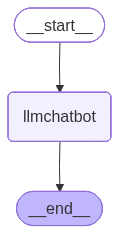

In [8]:
## visualize graph
from IPython.display import Image, display


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
resp = graph.invoke({"messages": "Hi"})

In [10]:
resp["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [11]:
for event in graph.stream({"messages": "Hi, How are you?"}):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 41, 'total_tokens': 79, 'completion_time': 0.088501415, 'completion_tokens_details': None, 'prompt_time': 0.009636379, 'prompt_tokens_details': None, 'queue_time': 0.164100331, 'total_time': 0.098137794}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eac3d-9ede-7422-8a49-435714992d0e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 38, 'total_tokens': 79})]}


In [9]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
resp = tool.invoke("What is langgraph?")

resp['results']

[{'url': 'https://www.ibm.com/think/topics/langgraph',
  'title': 'What is LangGraph? - IBM',
  'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigator charts out the optimal routes between points on the “Super-Map,” all of which are created by “The 

In [10]:
### Custom Function

def multiply(a:int, b:int) -> int:
    """Multipy a and b

    Args:
    a (int): first int
    b (int): second int

    Returns:
        int: result int
    """

In [12]:
tools = [tool, multiply]
llm_with_tools = model.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016459F8A7D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016459F8A6E0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

In [ ]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [ ]:
### StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


graph_builder = StateGraph(State)

## adding node
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))
## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
graph_builder.add_edge("tools", END)

## compile the graph
graph = graph_builder.compile()